# Ejemplo Maquinas de soporte vectorial para clasificacion SVM
## 1. Importar librerías

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

## 2. Crear datos NO linealmente separables

In [5]:
np.random.seed(42)

# Clase 0: círculo interno
r0 = 0.5 + 0.1*np.random.randn(100)
t0 = 2*np.pi*np.random.rand(100)
x0 = np.column_stack([r0*np.cos(t0), r0*np.sin(t0)])
y0 = np.zeros(100)

# Clase 1: anillo externo
r1 = 1.5 + 0.1*np.random.randn(100)
t1 = 2*np.pi*np.random.rand(100)
x1 = np.column_stack([r1*np.cos(t1), r1*np.sin(t1)])
y1 = np.ones(100)

# Dataset completo
X = np.vstack([x0, x1])
y = np.concatenate([y0, y1])



## 3. Visualización inicial (2D)

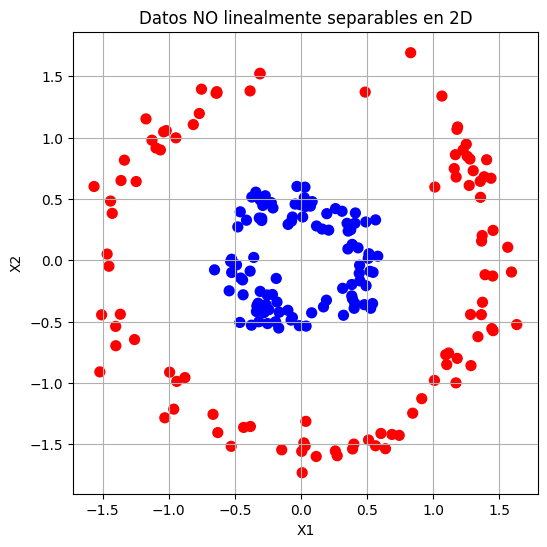

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", s=50)
plt.title("Datos NO linealmente separables en 2D")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()


## 4. Mapeo explícito (a 3D)
     φ(x) = (x1, x2, x1² + x2²)\
La instrucción **X_3D = np.column_stack([X[:,0], X[:,1], X[:,0]^2 + X[:,1]^2])** transforma un conjunto de datos originalmente bidimensional en un espacio tridimensional agregando una tercera característica no lineal, x² + y², que corresponde a un paraboloide; esta expansión es clave porque muchos datos que no son separables mediante una línea recta en 2D —por ejemplo, cuando las clases forman patrones circulares o curvos— sí se vuelven separables mediante un plano en 3D. Al añadir esta dimensión cuadrática, los puntos cercanos al centro “suben” y los lejanos “bajan”, produciendo una curvatura que permite que una frontera lineal en la nueva dimensión (un plano) represente una frontera no lineal en el espacio original. En esencia, esta línea de código ejemplifica el principio fundamental detrás del truco del kernel: mapear los datos a un espacio de mayor dimensionalidad donde la separación lineal sea posible, revelando cómo SVM puede manejar relaciones complejas sin necesidad de calcular explícitamente todas las transformaciones mediante el uso de kernels como el RBF.

In [7]:
X_3D = np.column_stack([X[:,0], X[:,1], X[:,0]**2 + X[:,1]**2])

## 5. Entrenar SVM LINEAL pero en el espacio 3D
En este fragmento, **modelo = SVC(kernel='linear')** crea un clasificador SVM que buscará separar los datos mediante un hiperplano estrictamente lineal en el espacio donde se le entreguen los datos; luego,**modelo.fit(X_3D, y)** entrena ese modelo usando las coordenadas tridimensionales ya transformadas y sus etiquetas, permitiendo que el algoritmo encuentre el plano óptimo que maximiza el margen entre las clases en ese espacio ampliado. Una vez entrenado, **w = modelo.coef_[0]** extrae el vector normal del hiperplano —es decir, los coeficientes que determinan la orientación del plano en 3D— y **b = modelo.intercept_[0]** obtiene el término de sesgo que ajusta la posición del plano en el espacio. En conjunto, w y b representan la ecuación del hiperplano **(w₁x + w₂y + w₃z + b = 0)** que separa linealmente las clases en la dimensionalidad aumentada, aunque en el espacio original corresponda a una frontera no lineal.

In [9]:
modelo = SVC(kernel='linear')
modelo.fit(X_3D, y)
# Coeficientes del hiperplano
w = modelo.coef_[0]
b = modelo.intercept_[0]

## 6. Graficar datos y plano separador en 3D

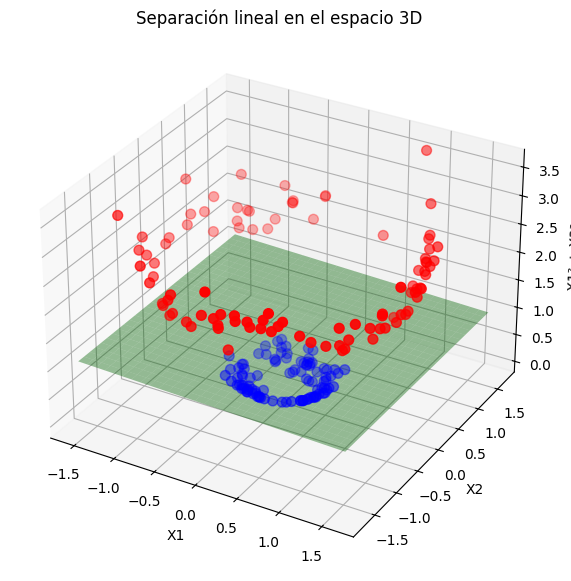

In [10]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Datos en 3D
ax.scatter(X_3D[:,0], X_3D[:,1], X_3D[:,2], c=y, cmap="bwr", s=50)

# Mallado para mostrar el plano w1*x + w2*y + w3*z + b = 0
xx, yy = np.meshgrid(
    np.linspace(min(X_3D[:,0]), max(X_3D[:,0]), 30),
    np.linspace(min(X_3D[:,1]), max(X_3D[:,1]), 30)
)

# z despejado de: w1*x + w2*y + w3*z + b = 0
zz = (-w[0]*xx - w[1]*yy - b) / w[2]

ax.plot_surface(xx, yy, zz, alpha=0.4, color="green")

ax.set_title("Separación lineal en el espacio 3D")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X1² + X2²")
plt.show()